### **Notebook Session 4 - Decission Trees**

Data: url [Titanic Machine Learning from Disaster]{https://www.kaggle.com/competitions/titanic/data}

Application of decission Trees

In [1]:
# imports
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree


#### **Data Import**

In [2]:
df_train = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

In [3]:
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df_train.shape

(891, 12)

#### **EDA**

In [7]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

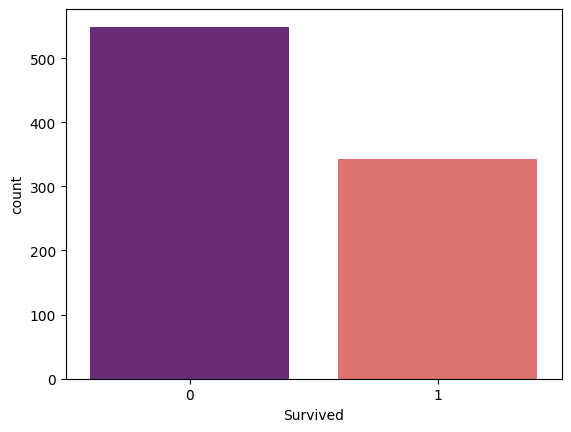

In [8]:
sns.countplot(data=df_train, x='Survived', hue='Survived', palette='magma', legend=False)

<Axes: >

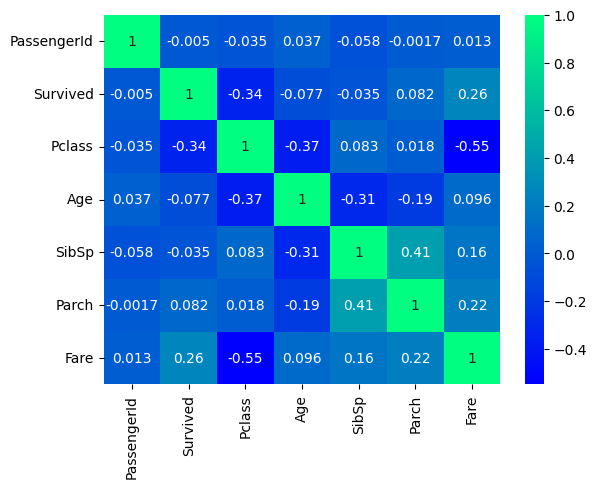

In [9]:
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='winter')

#### **Data Cleansing and Feature engineering**

In [10]:
# For data cleansing and Feature engineering we use Test and Train together
# Combine them and add a 'train' column to keep track of which is which
df_train['is_train'] = 1
test_df['is_train'] = 0

# Concatenate vertically (axis=0 is the default)
all_data = pd.concat([df_train, test_df], axis=0).reset_index(drop=True)

# Check the results
print(f"Combined shape: {all_data.shape}")
print(all_data['is_train'].value_counts())
all_data
all_data = all_data.drop('Survived', axis=1)

Combined shape: (1309, 13)
is_train
1    891
0    418
Name: count, dtype: int64


In [11]:
((all_data.isnull().sum())/len(all_data))*100

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
is_train        0.000000
dtype: float64

In [12]:
all_data.drop('Cabin',axis=1,inplace=True)

In [13]:
all_data['Age'] = all_data['Age'].fillna(all_data['Age'].mean())

In [14]:
((all_data.isnull().sum())/len(all_data))*100

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.076394
Embarked       0.152788
is_train       0.000000
dtype: float64

In [15]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1309 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Embarked     1307 non-null   object 
 10  is_train     1309 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 112.6+ KB


In [16]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [17]:
nan_percent= missing_percent(all_data)


In [18]:
nan_percent

Fare        0.076394
Embarked    0.152788
dtype: float64

In [19]:
all_data.drop(['PassengerId','Name','Ticket','Fare','Embarked'],axis=1, inplace=True)

In [20]:
all_data.loc[all_data['Sex']=='male','Sex']=1
all_data.loc[all_data['Sex']=='female','Sex']=0

In [21]:
def missing_percent(df):
    nan_percent=((df.isnull().sum())/len(df))*100
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [22]:
nan_percent= missing_percent(all_data)

In [23]:
all_data.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
is_train    0
dtype: int64

In [24]:
nan_percent

Series([], dtype: float64)

In [25]:
X = all_data[all_data["is_train"]==1]
y = df_train['Survived']
X_final = all_data[all_data["is_train"]==0]

X = X.drop('is_train', axis=1)
X_final = X_final.drop('is_train', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

#### **Feature scaling**

In [29]:
# is it needed for DTrees? Try it with and without and guess
scaler = StandardScaler()
scaler.fit(X)

scaled_X_train= scaler.transform(X_train)
scaled_X_test= scaler.transform(X_test)
scaled_X = scaler.transform(X)
scaled_X_final = scaler.transform(X_final)

#### **Model -Decision Trees-**

In [30]:
DT = DecisionTreeClassifier()
DT.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred = DT.predict(X_test)
cm = confusion_matrix(y_test,y_pred)

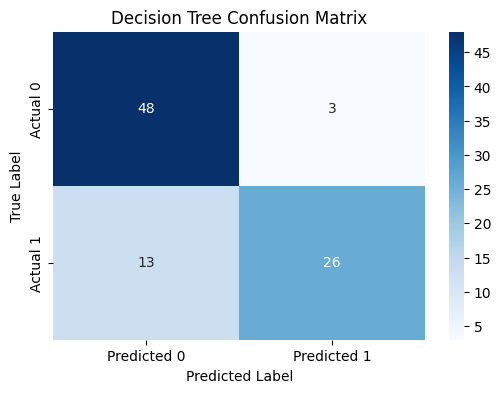

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86        51
           1       0.90      0.67      0.76        39

    accuracy                           0.82        90
   macro avg       0.84      0.80      0.81        90
weighted avg       0.83      0.82      0.82        90



In [34]:
DT.feature_importances_

array([0.14760534, 0.37852282, 0.33081462, 0.09495846, 0.04809875])

In [35]:
pd.DataFrame(index=X_train.columns,data=DT.feature_importances_,columns=['Feature Importance'])

,Feature Importance
Pclass,0.147605
Sex,0.378523
Age,0.330815
SibSp,0.094958
Parch,0.048099


#### **Tree Visualization**

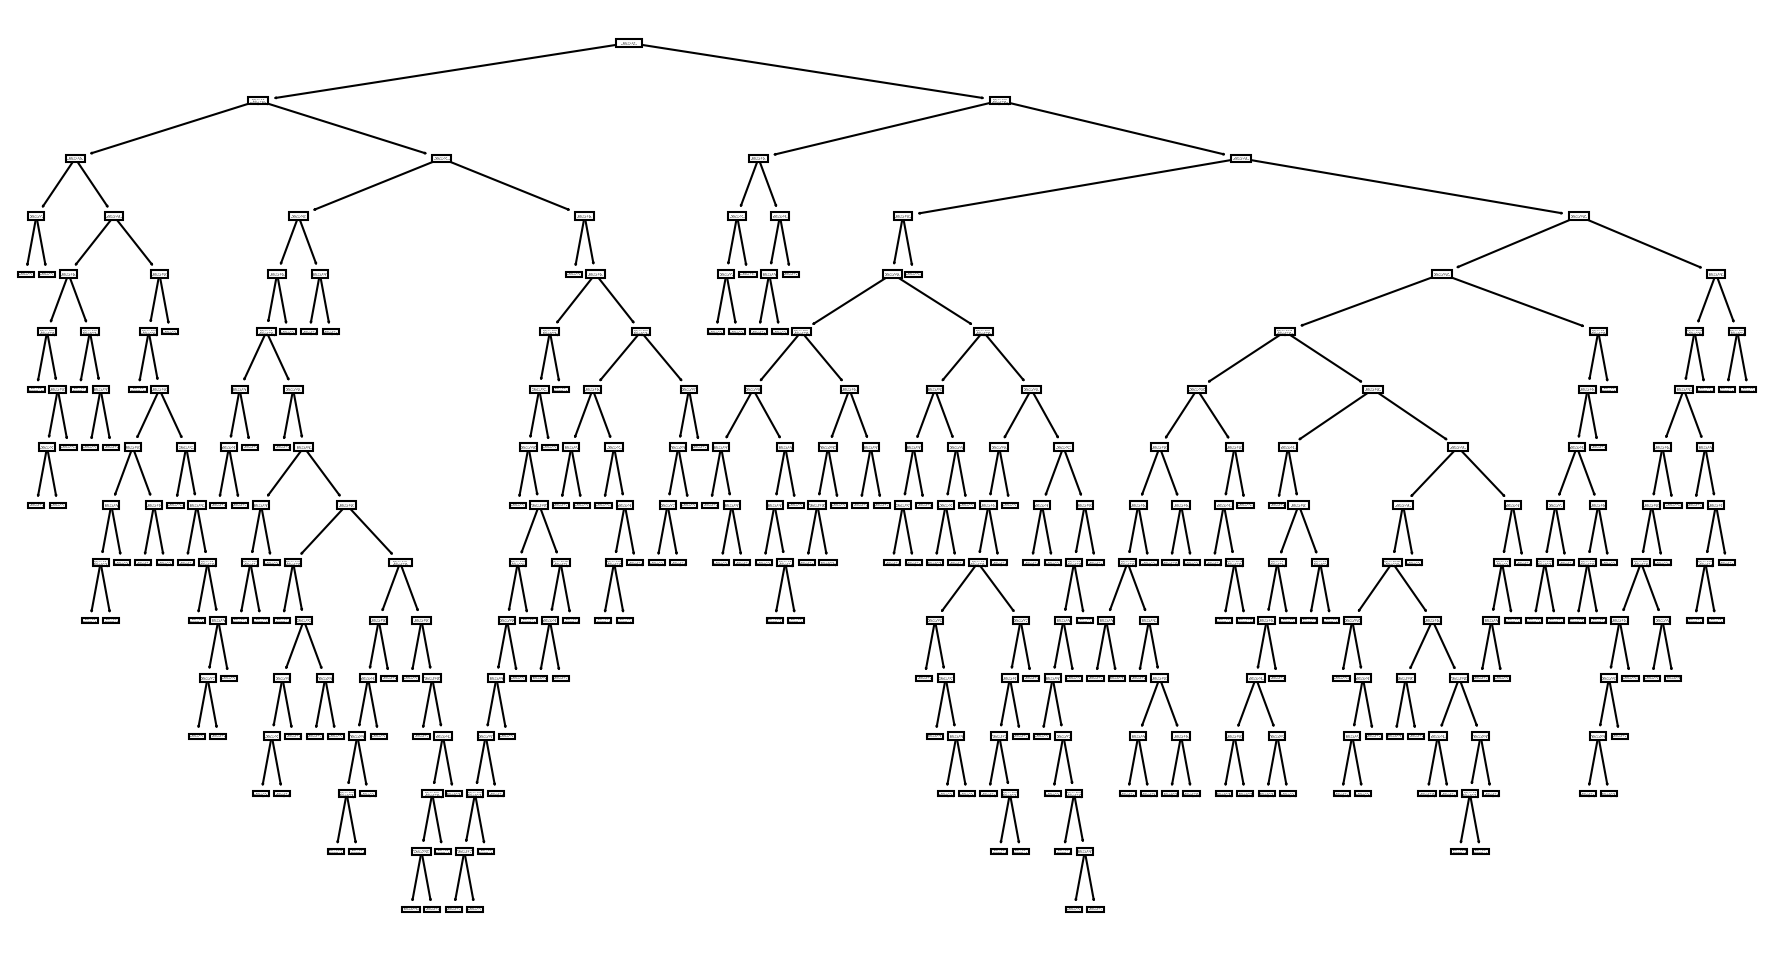

In [36]:
plt.figure(figsize=(15,8),dpi=150)
plot_tree(DT);

In [37]:
def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=X_test.columns);

#### **Hyperparameter impact**

In [38]:
# See impact of Max_Depth
pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

           0       0.68      0.92      0.78        51
           1       0.81      0.44      0.57        39

    accuracy                           0.71        90
   macro avg       0.75      0.68      0.68        90
weighted avg       0.74      0.71      0.69        90





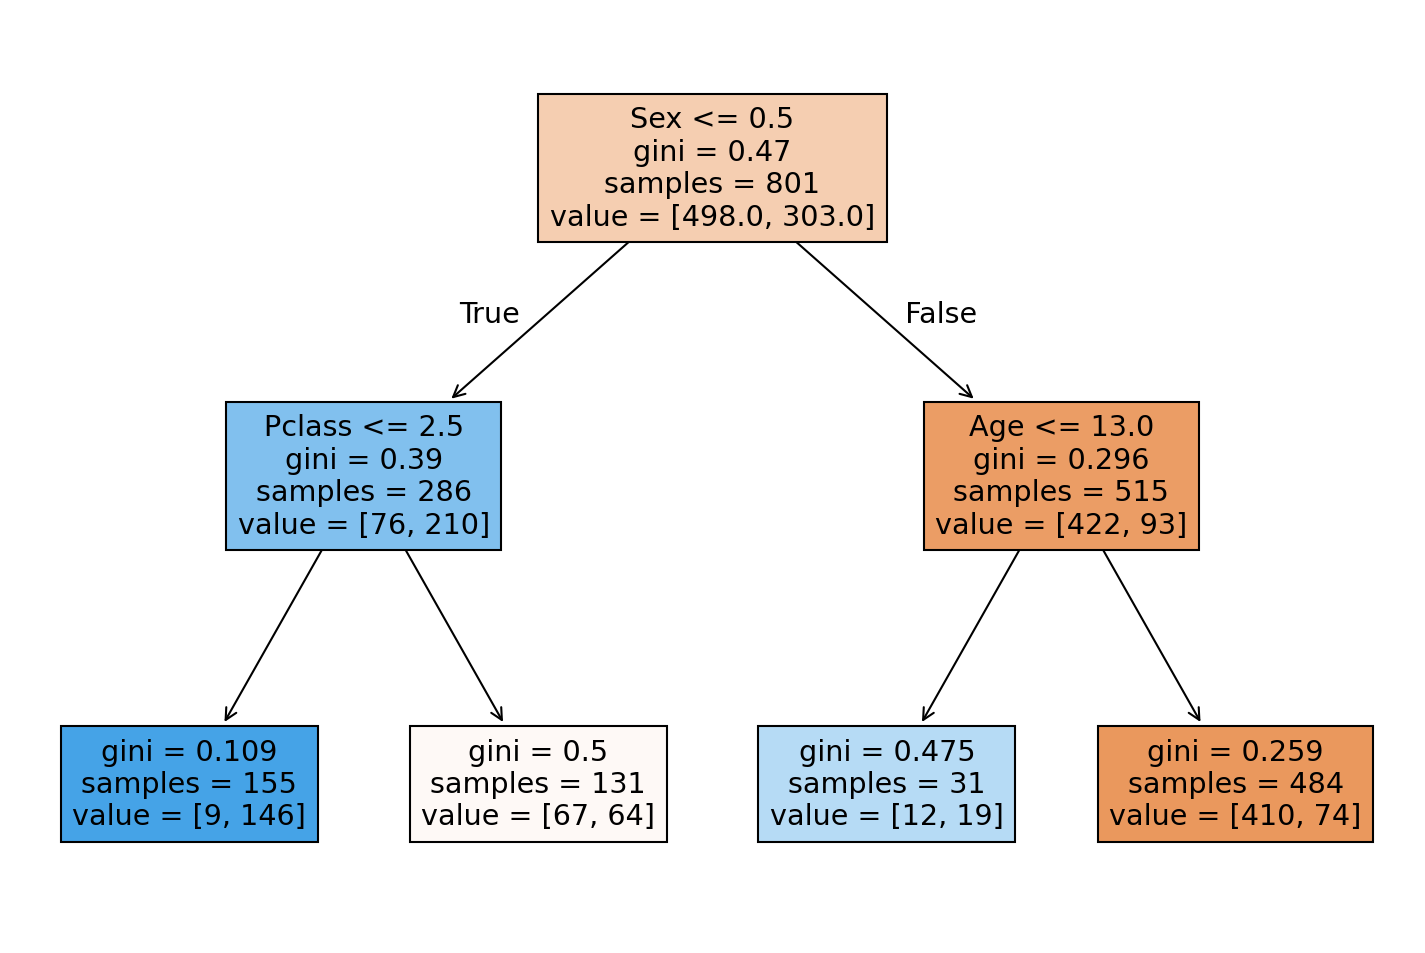

In [39]:
report_model(pruned_tree)

In [40]:
#Max Leaf Nodes
pruned_tree = DecisionTreeClassifier(max_leaf_nodes=3)
pruned_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,3
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

           0       0.68      1.00      0.81        51
           1       1.00      0.38      0.56        39

    accuracy                           0.73        90
   macro avg       0.84      0.69      0.68        90
weighted avg       0.82      0.73      0.70        90





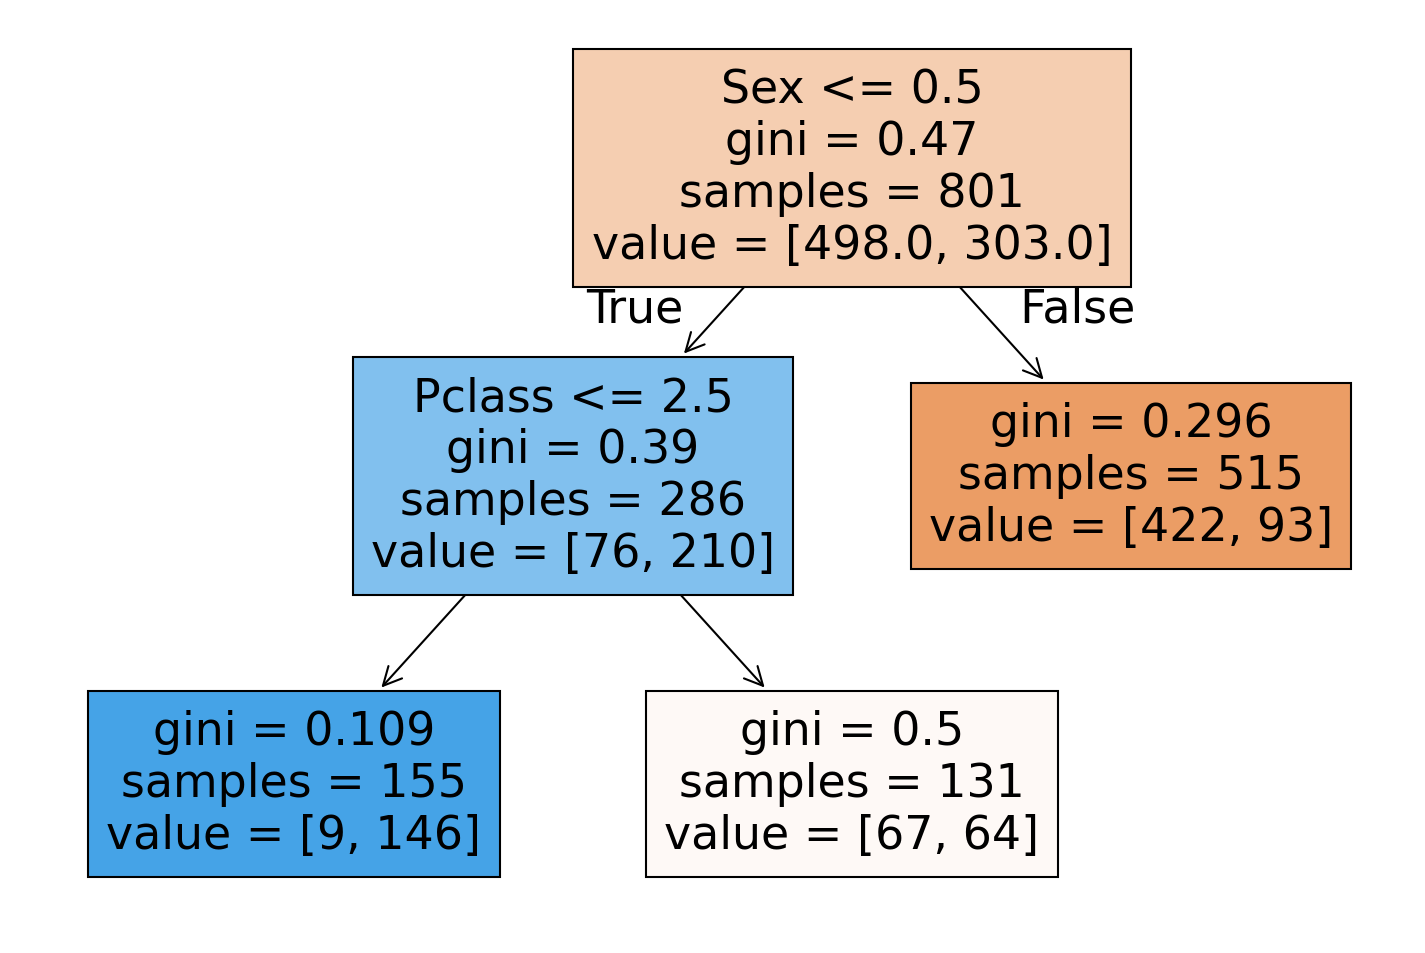

In [41]:
report_model(pruned_tree)

In [42]:
# Entropy
entropy_tree = DecisionTreeClassifier(criterion='entropy')
entropy_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

           0       0.79      0.96      0.87        51
           1       0.93      0.67      0.78        39

    accuracy                           0.83        90
   macro avg       0.86      0.81      0.82        90
weighted avg       0.85      0.83      0.83        90





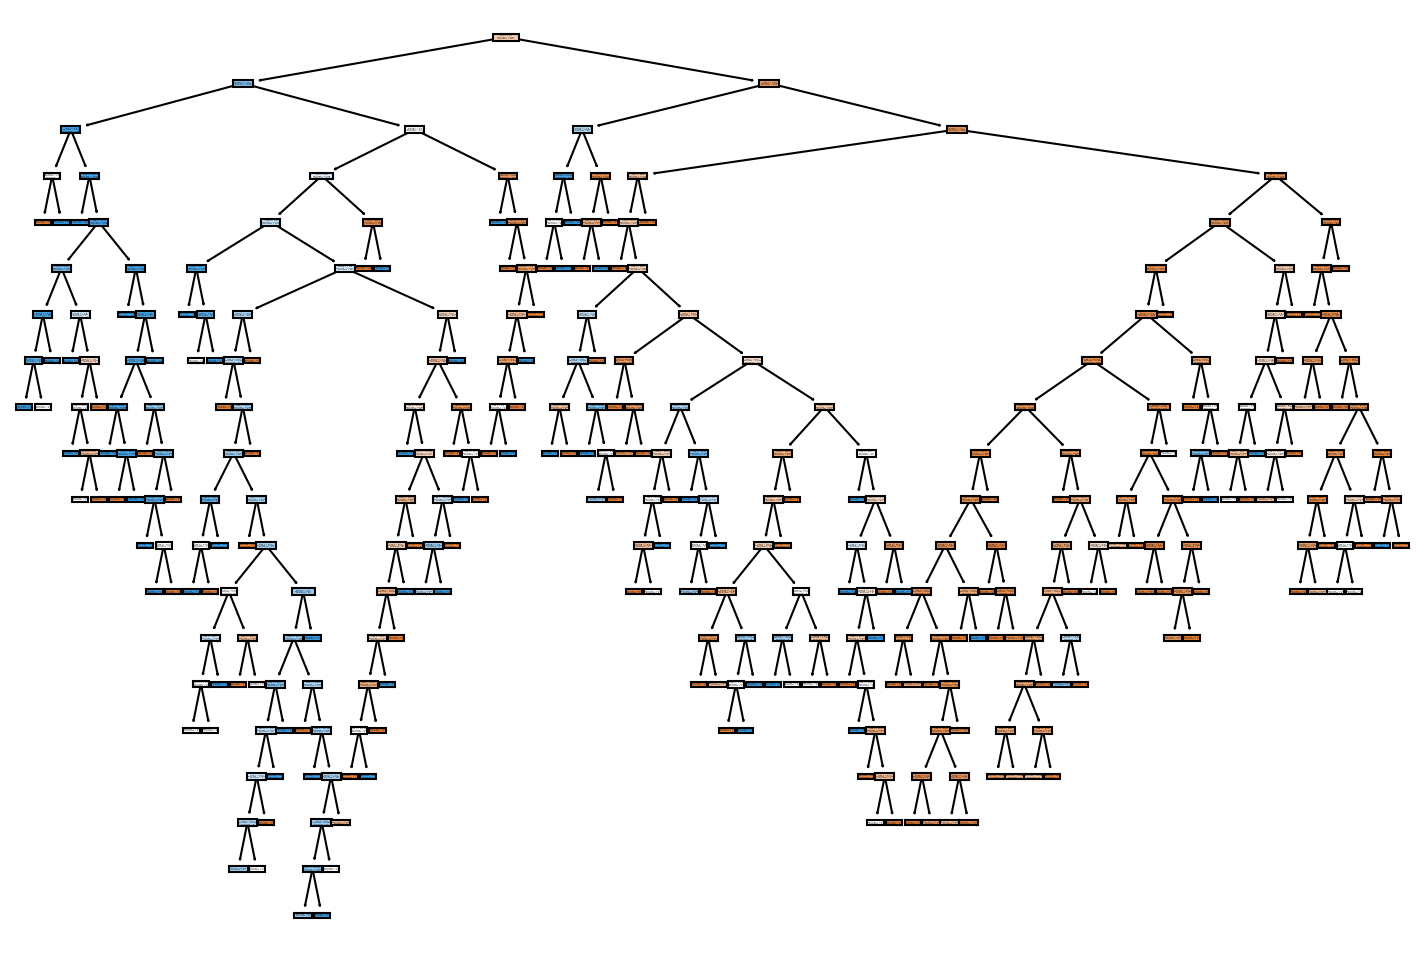

In [43]:
report_model(entropy_tree)

#### **Submission**

In [44]:
# Training model on X (all data)
DT = DecisionTreeClassifier()
DT.fit(X,y)

print("Generating predictions on submission test set...")
y_test_pred = DT.predict(X_final)

Generating predictions on submission test set...


In [45]:
# Save predictions to CSV using the save_csv snippet
def results_to_csv(y_test, passenger_ids, file_name):
    """
    Save predictions to Kaggle-accepted CSV format.
    passenger_ids: The 'PassengerId' column from your original test.csv
    """
    # Create the DataFrame with the exact required names
    df = pd.DataFrame({
        'PassengerId': passenger_ids,
        'Survived': y_test.astype(int)
    })
    
    # Save without the pandas index, since PassengerId is now a column
    df.to_csv(file_name, index=False)
    
    print(f"Predictions saved to {file_name}")
    return df

In [46]:
# Create submission file
ts = datetime.now().strftime("%Y%m%d%H%M%S")
sub_name = 'submission'+ts+'.csv'
passenger_ids = test_df['PassengerId']
submission_df = results_to_csv(y_test_pred, passenger_ids, sub_name)

# Display first few rows
print("\nSubmission file preview:")
print(submission_df.head(10))

Predictions saved to submission20260207093843.csv

Submission file preview:
   PassengerId  Survived
0          892         0
1          893         0
2          894         1
3          895         1
4          896         1
5          897         0
6          898         0
7          899         0
8          900         0
9          901         0


==========================================================
#### **TODO**
==========================================================

This example gets around 73% in Kaggle give it a try and see how much you get

1. Try scaling and not scaling What do you see?
2. Try Random Forest. Does it improve?
3. Any ideas to improve feature engineering?
4. Did you get closer to 80%
